<a href="https://colab.research.google.com/github/s-hreya184/AEROZEN/blob/main/Demo_Insurance_Vulnerability_Score.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

Synthetic Policy Dataset Generation

In [ ]:
np.random.seed(42)

data_size = 200

waiting_period = np.random.randint(0, 48, data_size)  # months
copay = np.random.randint(0, 35, data_size)  # percentage
room_rent = np.random.randint(3000, 15000, data_size)  # per day
policy_limit = np.random.randint(200000, 1000000, data_size)

# Create synthetic risk score logic (hidden real logic)
score = (
    waiting_period * 0.8 +
    copay * 1.5 +
    (10000 - room_rent) * 0.002 +
    (500000 - policy_limit) * 0.00005
)

score = np.clip(score, 0, 100)

df = pd.DataFrame({
    "waiting_period": waiting_period,
    "copay": copay,
    "room_rent": room_rent,
    "policy_limit": policy_limit,
    "risk_score": score
})

df.head()


,waiting_period,copay,room_rent,policy_limit,risk_score
0,38,11,6506,648345,46.47075
1,28,1,10253,949074,0.94030
2,14,2,5744,687462,13.33890
3,42,16,14548,739773,36.51535
4,7,1,12435,286188,12.92060


Model Training

In [ ]:
X = df[["waiting_period", "copay", "room_rent", "policy_limit"]]
y = df["risk_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Mean Absolute Error:", mean_absolute_error(y_test, predictions))

Mean Absolute Error: 1.1233686525702258


Risk Prediction

In [ ]:
sample_policy = pd.DataFrame({
    "waiting_period": [36],
    "copay": [20],
    "room_rent": [5000],
    "policy_limit": [500000]
})

predicted_score = model.predict(sample_policy)

print("Predicted Vulnerability Score:", int(predicted_score[0]))

Predicted Vulnerability Score: 67


Risk Classification


In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

importance

,Feature,Coefficient
0,waiting_period,0.763031
1,copay,1.440640
2,room_rent,-0.001820
3,policy_limit,-0.000048


In [ ]:
sample_values = sample_policy.values.flatten()
feature_names = sample_policy.columns

Heatmap Visualization

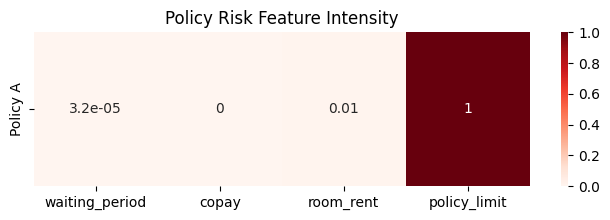

In [ ]:
import seaborn as sns
normalized = (sample_values - np.min(sample_values)) / (np.max(sample_values) - np.min(sample_values))

heat_data = normalized.reshape(1, -1)

plt.figure(figsize=(8,2))
sns.heatmap(heat_data, annot=True, cmap="Reds", xticklabels=feature_names, yticklabels=["Policy A"])
plt.title("Policy Risk Feature Intensity")
plt.show()

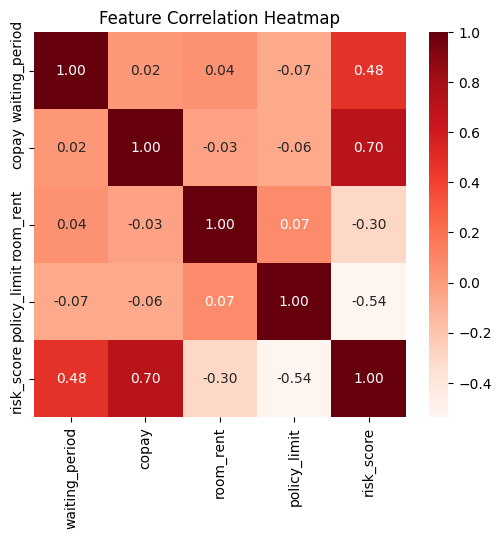

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,5))
corr = df.corr()

sns.heatmap(corr, annot=True, cmap="Reds", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()